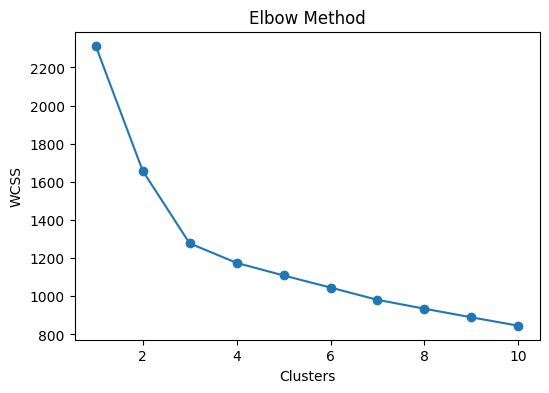

KMeans Silhouette Score: 0.2848589191898987


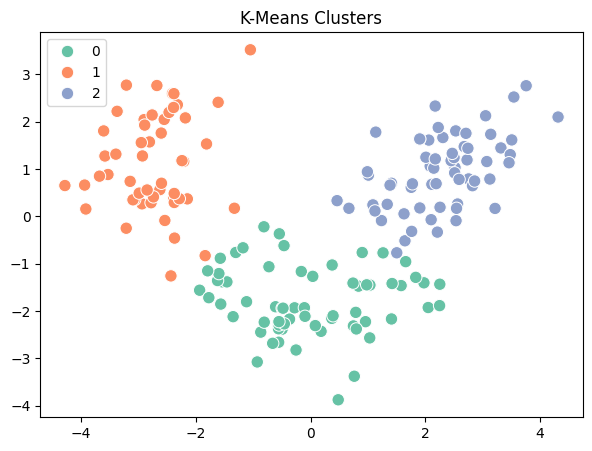

DBSCAN Silhouette Score: 0.34801201341316823


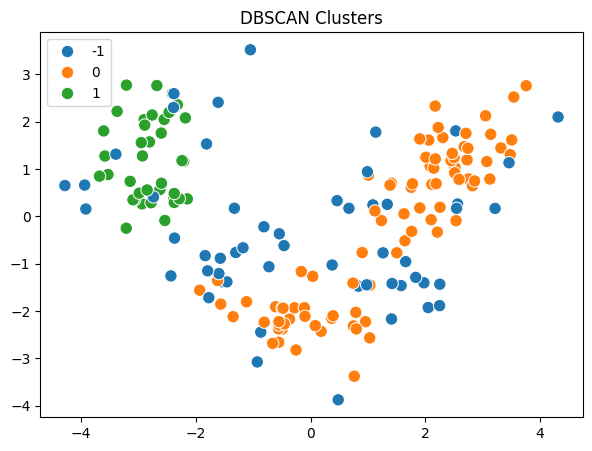

                  alcohol  malic_acid       ash  alcalinity_of_ash  \
KMeans_Cluster                                                       
0               12.250923    1.897385  2.231231          20.063077   
1               13.134118    3.307255  2.417647          21.241176   
2               13.676774    1.997903  2.466290          17.462903   

                 magnesium  total_phenols  flavanoids  nonflavanoid_phenols  \
KMeans_Cluster                                                                
0                92.738462       2.247692    2.050000              0.357692   
1                98.666667       1.683922    0.818824              0.451961   
2               107.967742       2.847581    3.003226              0.292097   

                proanthocyanins  color_intensity       hue  \
KMeans_Cluster                                               
0                      1.624154         2.973077  1.062708   
1                      1.145882         7.234706  0.691961   
2    

In [4]:
!pip -q install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

X = StandardScaler().fit_transform(df)

wcss = []
for i in range(1, 11):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit(X)
    wcss.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(X)
print("KMeans Silhouette Score:", silhouette_score(X, k_labels))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=k_labels, palette="Set2", s=80)
plt.title("K-Means Clusters")
plt.show()

dbscan = DBSCAN(eps=2.2, min_samples=5)
d_labels = dbscan.fit_predict(X)

if len(set(d_labels)) > 2:
    print("DBSCAN Silhouette Score:", silhouette_score(X[d_labels!=-1], d_labels[d_labels!=-1]))

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=d_labels, palette="tab10", s=80)
plt.title("DBSCAN Clusters")
plt.show()

df["KMeans_Cluster"] = k_labels
df["DBSCAN_Cluster"] = d_labels

print(df.groupby("KMeans_Cluster").mean())

df.to_csv("Customer_Clusters_Output.csv", index=False)

print(df.head())